In [ ]:
# Import required libraries
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# 1. Load Breast Cancer Dataset
data = load_breast_cancer()

In [ ]:
X = data.data        # Features
y = data.target      # Target (0 = malignant, 1 = benign)

In [ ]:
# 2. Convert into DataFrame (optional)
df = pd.DataFrame(X, columns=data.feature_names)

print(df.head())

print("\nTarget Classes:")
print(data.target_names)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [ ]:
# 3. Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# 4. Feature Scaling
# Important because logistic regression uses distance-based optimization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 5. Create Logistic Regression Model
model = BreastCancerLogisticRegression(learning_rate=0.01, epochs=10000, tolerance=1e-7)

In [ ]:
# 6. Train the model
# Internally it finds beta0 and beta1 values
model.fit(X_train, y_train)

In [ ]:
# 7. Prediction
y_pred = model.predict(X_test)

In [ ]:
# 8. Probability Prediction
probability = model.predict_proba(X_test)

In [ ]:
# Display first 5 probabilities
print("\nPredicted Probabilities:")
print(probability[:5])


Predicted Probabilities:
[[1.13590250e-01 8.86409750e-01]
 [9.99990991e-01 9.00936206e-06]
 [9.96920905e-01 3.07909541e-03]
 [5.10134225e-04 9.99489866e-01]
 [6.06389713e-05 9.99939361e-01]]


In [ ]:
# 9. Model Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


Accuracy: 0.9736842105263158


In [ ]:
# 10. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[41  2]
 [ 1 70]]


In [ ]:
# 11. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



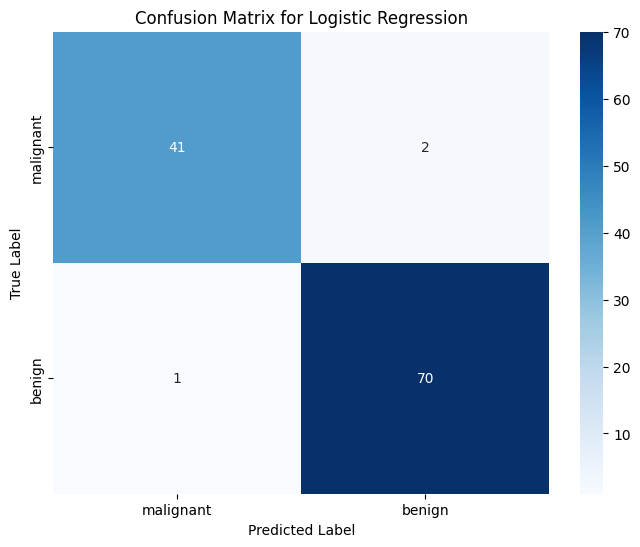

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
print(model.coef_)

Intercept:
[0.44558453]

Coefficients:
[[-0.43190368 -0.38732553 -0.39343248 -0.46521006 -0.07166728  0.54016395
  -0.8014581  -1.11980408  0.23611852  0.07592093 -1.26817815  0.18887738
  -0.61058302 -0.9071857  -0.31330675  0.68249145  0.17527452 -0.3112999
   0.50042502  0.61622993 -0.87984024 -1.35060559 -0.58945273 -0.84184594
  -0.54416967  0.01611019 -0.94305313 -0.77821726 -1.20820031 -0.15741387]]


In [ ]:
# Take one sample
sample = X_test[0]

# Calculate z
z = np.dot(model.coef_, sample) + model.intercept_

print("z value:", z)


# Apply sigmoid
prob = 1/(1+np.exp(-z))

print("Probability:", prob)

z value: [2.05458164]
Probability: [0.88640975]


### Visualizing the Sigmoid Function

The sigmoid function transforms the linear combination of features and coefficients (z-value) into a probability between 0 and 1. This visualization helps understand how `z` is mapped to a probability.

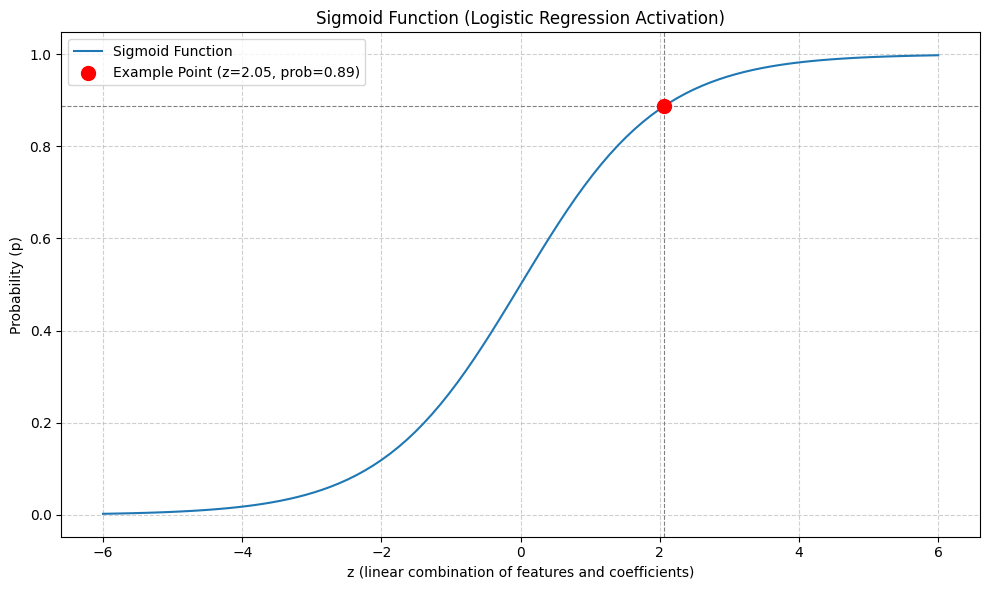

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate a range of z values
z_values = np.linspace(-6, 6, 100)

# Calculate sigmoid probabilities for these z values
sigmoid_probs = sigmoid(z_values)

plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_probs, label='Sigmoid Function')

# Highlight the 'z' value and probability from the example
plt.scatter(z, prob, color='red', s=100, zorder=5, label=f'Example Point (z={z[0]:.2f}, prob={prob[0]:.2f})')
plt.axvline(x=z[0], color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=prob[0], color='gray', linestyle='--', linewidth=0.8)

plt.title('Sigmoid Function (Logistic Regression Activation)')
plt.xlabel('z (linear combination of features and coefficients)')
plt.ylabel('Probability (p)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

 Custom Logistic Regression Class Definition using Gradient Descent

In [ ]:
class BreastCancerLogisticRegression:
    def __init__(self, learning_rate=0.1, epochs=1000, tolerance=1e-6):
        self.lr = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        # Step 3: Sigmoid Activation Function
        # Maps infinite z scores to the crisp (0, 1) probability scale
        return 1 / (1 + np.exp(-np.clip(z, -250, 250))) # Clip to prevent numeric overflow

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Step 1: Parameter Initialization
        # Start weights at zero vector and bias at a single float zero
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        # Step 6: Iterative Optimization Loop
        for epoch in range(self.epochs):
            # Step 2: Linear Combination (z = Xw + b)
            z = np.dot(X, self.weights) + self.bias

            # Step 3: Activation Phase/Sigmoid function
            y_pred = self._sigmoid(z)

            # Step 4: Calculate Loss (Binary Cross-Entropy / Log Loss)
            # Add small epsilon to prevent math errors like log(0)
            eps = 1e-15
            y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
            loss = - (1 / n_samples) * np.sum(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
            self.loss_history.append(loss)

            # Step 5: Optimization via Gradient Descent
            # Calculate partial derivatives (gradients) of the loss with respect to w and b
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update parameters by taking a step in the direction opposite to gradients
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Check for Convergence (Stop early if loss reduction is negligible)
            if epoch > 0 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tolerance:
                print(f"-> Model converged early at epoch {epoch}!")
                break

    def predict_prob(self, X):
        # Generate raw probabilities for inference
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        # Step 7: Decision Boundary & Prediction Labeling
        # Assign 1 (Benign) if probability >= 0.5, else assign 0 (Malignant)
        probabilities = self.predict_prob(X)
        return np.where(probabilities >= threshold, 1, 0)

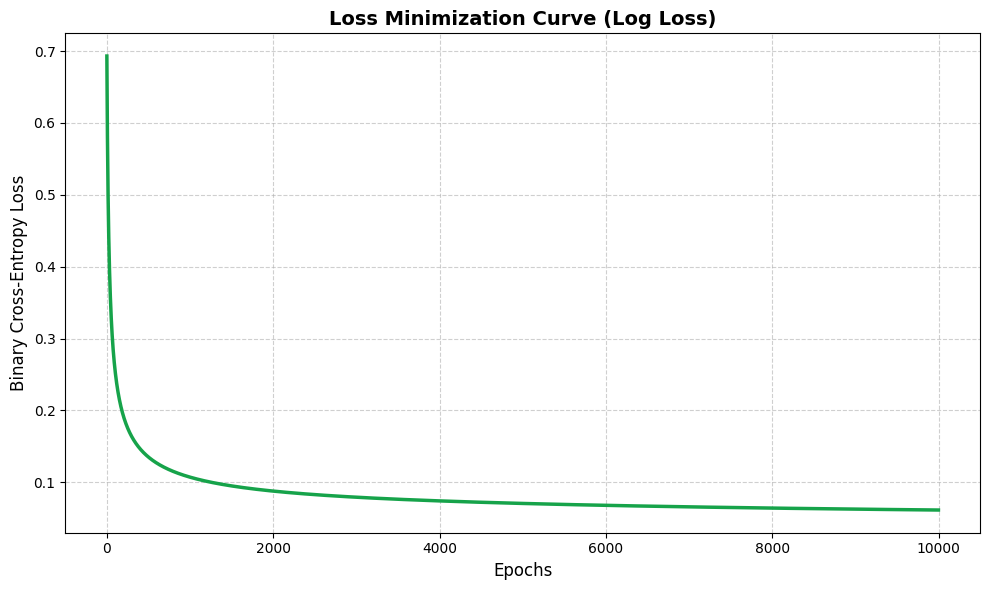

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(model.loss_history, color='#16a34a', linewidth=2.5)
plt.title("Loss Minimization Curve (Log Loss)", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()